In [1]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from tqdm import tqdm
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.use_deterministic_algorithms(True)

set_seed(SEED)


## 1. Data Loading

Load hyperspectral data with spatial structure preserved for neighborhood extraction.

In [3]:
def load_hsi_data(data_path):
    """Load HSI data from ENVI format."""
    import spectral
    img = spectral.open_image(data_path)
    data = img.load()
    return np.array(data, dtype=np.float32)

def load_label(label_path):
    """Load label data."""
    return np.load(label_path)

def calibrate_hsi(data, white_ref_path, dark_ref_path):
    """Calibrate HSI data using white and dark references."""
    import spectral
    white_ref = np.array(spectral.open_image(white_ref_path).load(), dtype=np.float32)
    dark_ref = np.array(spectral.open_image(dark_ref_path).load(), dtype=np.float32)
    
    # Average across spatial dimensions
    white_mean = white_ref.mean(axis=(0, 1))
    dark_mean = dark_ref.mean(axis=(0, 1))
    
    # Calibration
    calibrated = (data - dark_mean) / (white_mean - dark_mean + 1e-8)
    calibrated = np.clip(calibrated, 0, 1)
    
    return calibrated

In [4]:
class HSISpatialDataset(Dataset):
    """Dataset that extracts spatial neighborhoods around each pixel."""
    
    def __init__(self, data, labels=None, neighborhood_radius=1):
        """
        Args:
            data: HSI data of shape (H, W, B)
            labels: Label array of shape (H, W) or None
            neighborhood_radius: Radius of spatial neighborhood (default 1 -> 3x3)
        """
        self.data = data
        self.labels = labels
        self.neighborhood_radius = neighborhood_radius
        self.H, self.W, self.B = data.shape
        
        # Compute valid center pixels (excluding border)
        r = neighborhood_radius
        self.valid_pixels = []
        for i in range(r, self.H - r):
            for j in range(r, self.W - r):
                self.valid_pixels.append((i, j))
        
        if labels is not None:
            self.pixel_labels = labels
        else:
            self.pixel_labels = None
        
        self.shape = (self.H, self.W)
    
    def __len__(self):
        return len(self.valid_pixels)
    
    def __getitem__(self, idx):
        i, j = self.valid_pixels[idx]
        r = self.neighborhood_radius
        
        # Extract spatial neighborhood: (2r+1) x (2r+1) x B
        neighborhood = self.data[i-r:i+r+1, j-r:j+r+1, :]  # (2r+1, 2r+1, B)
        
        # Reshape to (K, B) where K = (2r+1)^2
        K = (2 * r + 1) ** 2
        neighborhood_flat = neighborhood.reshape(K, self.B)  # (K, B)
        
        neighborhood_flat = torch.from_numpy(neighborhood_flat).float()
        
        if self.pixel_labels is not None:
            label = torch.tensor(self.pixel_labels[i, j], dtype=torch.long)
            return neighborhood_flat, label
        else:
            return neighborhood_flat

In [5]:
# Load data for a specific food type
food_type = 'Almond'  # Change to 'Pistachio' or 'GarlicStems' as needed

base_path = f'../../AnomalyonFood/Dataset/{food_type}'

# Load training data (normal only)
train_data_path = f'{base_path}/Train/data.hdr'
train_white_path = f'{base_path}/Train/WHITEREF.hdr'
train_dark_path = f'{base_path}/Train/DARKREF.hdr'

print(f'Loading {food_type} training data...')
train_data = load_hsi_data(train_data_path)
train_data = calibrate_hsi(train_data, train_white_path, train_dark_path)

# Load test data (normal + anomalies)
test_data_path = f'{base_path}/Test/data.hdr'
test_white_path = f'{base_path}/Test/WHITEREF.hdr'
test_dark_path = f'{base_path}/Test/DARKREF.hdr'
test_label_path = f'{base_path}/Test/label.npy'

print(f'Loading {food_type} test data...')
test_data = load_hsi_data(test_data_path)
test_data = calibrate_hsi(test_data, test_white_path, test_dark_path)
test_labels = load_label(test_label_path)

print(f'Train data shape: {train_data.shape}')
print(f'Test data shape: {test_data.shape}')
print(f'Test labels shape: {test_labels.shape}')
print(f'Number of bands: {train_data.shape[2]}')

Loading Almond training data...


/home/alfi/miniforge3/envs/rapidsai/lib/python3.13/site-packages/spectral/io/envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


Loading Almond test data...
Train data shape: (400, 512, 224)
Test data shape: (400, 512, 224)
Test labels shape: (400, 512)
Number of bands: 224


In [6]:
# Create datasets with spatial neighborhoods
neighborhood_radius = 1  # 3x3 neighborhood

train_dataset = HSISpatialDataset(train_data, neighborhood_radius=neighborhood_radius)
test_dataset = HSISpatialDataset(test_data, test_labels, neighborhood_radius=neighborhood_radius)

print(f'Training pixel locations: {len(train_dataset)}')
print(f'Test pixel locations: {len(test_dataset)}')
neighborhood_sample, _ = test_dataset[0]
print(f'Neighborhood size: {neighborhood_radius}x{neighborhood_radius} (K={neighborhood_sample.shape[0]} pixels)')
print(f'Spectrum dimension: {neighborhood_sample.shape[1]}')

# Create dataloaders
batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

Training pixel locations: 202980
Test pixel locations: 202980
Neighborhood size: 1x1 (K=9 pixels)
Spectrum dimension: 224


## 2. PA2E + Spatial Model Architecture

### Components:
1. **Partial Encoder** (shared across all neighbors)
2. **Aggregate Encoder** (single FC layer)
3. **Decoder** (mirror of encoder, used only during training)

In [7]:
class PartialEncoder(nn.Module):
    """Shared spectral encoder for individual pixels in neighborhood."""
    
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
    
    def forward(self, x):
        """
        Args:
            x: (batch, K, input_dim) where K is neighborhood size
        Returns:
            z_local: (batch, K, latent_dim)
        """
        batch_size, K, _ = x.shape
        
        # Flatten to (batch*K, input_dim)
        x_flat = x.view(-1, x.shape[-1])
        
        # Encode all pixels with shared weights
        z_flat = self.encoder(x_flat)  # (batch*K, latent_dim)
        
        # Reshape back to (batch, K, latent_dim)
        z_local = z_flat.view(batch_size, K, -1)
        
        return z_local

In [8]:
class SpatialPA2E(nn.Module):
    """PA2E model with spatial neighborhoods and DSVDD center-based scoring."""
    
    def __init__(self, input_dim, neighborhood_size=9, 
                 hidden_dim=128, latent_local_dim=32, latent_global_dim=64):
        super().__init__()
        
        self.input_dim = input_dim
        self.neighborhood_size = neighborhood_size
        self.latent_local_dim = latent_local_dim
        self.latent_global_dim = latent_global_dim
        
        # 1. Shared partial encoder (spectral encoding of each neighborhood pixel)
        self.partial_encoder = PartialEncoder(input_dim, hidden_dim, latent_local_dim)
        
        # 2. Aggregate encoder (SINGLE FC layer, as per paper)
        concat_dim = neighborhood_size * latent_local_dim
        self.aggregate_encoder = nn.Linear(concat_dim, latent_global_dim)
        
        # 3. Aggregate decoder (mirror of aggregate encoder)
        self.aggregate_decoder = nn.Linear(latent_global_dim, concat_dim)
        
        # 4. Partial decoder (mirror of partial encoder)
        self.partial_decoder = nn.Sequential(
            nn.Linear(latent_local_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )
        
        # 5. Center for DSVDD (initialized during training)
        self.register_buffer('center', torch.zeros(latent_global_dim))
        self.center_initialized = False
    
    def encode(self, neighborhood):
        """
        Encode spatial neighborhood to latent representation.
        
        Args:
            neighborhood: (batch, K, input_dim)
        Returns:
            z: (batch, latent_global_dim)
            z_local: (batch, K, latent_local_dim)
        """
        # Encode each pixel in neighborhood (shared weights)
        z_local = self.partial_encoder(neighborhood)  # (batch, K, latent_local_dim)
        
        # Flatten and concatenate
        batch_size = neighborhood.size(0)
        z_concat = z_local.view(batch_size, -1)  # (batch, K * latent_local_dim)
        
        # Aggregate with single FC layer
        z = self.aggregate_encoder(z_concat)  # (batch, latent_global_dim)
        
        return z, z_local
    
    def decode(self, z, z_local=None):
        """
        Decode latent representation to reconstructed neighborhood.
        
        Args:
            z: (batch, latent_global_dim)
            z_local: Optional, for direct decoding from local latents
        Returns:
            reconstructed: (batch, K, input_dim)
        """
        if z_local is None:
            # Go through aggregate decoder
            batch_size = z.size(0)
            z_concat = self.aggregate_decoder(z)  # (batch, K * latent_local_dim)
            z_local = z_concat.view(batch_size, self.neighborhood_size, self.latent_local_dim)
        
        batch_size, K, _ = z_local.shape
        
        # Decode each local latent (shared decoder weights)
        z_local_flat = z_local.view(-1, self.latent_local_dim)  # (batch*K, latent_local_dim)
        recon_flat = self.partial_decoder(z_local_flat)  # (batch*K, input_dim)
        reconstructed = recon_flat.view(batch_size, K, self.input_dim)
        
        return reconstructed
    
    def forward(self, neighborhood):
        """Forward pass: encode -> decode."""
        z, z_local = self.encode(neighborhood)
        reconstructed = self.decode(z, z_local)
        return z, reconstructed
    
    def compute_anomaly_score(self, neighborhood):
        """Compute anomaly score as distance to DSVDD center."""
        z, _ = self.encode(neighborhood)
        
        # Distance to center
        dist = torch.sum((z - self.center) ** 2, dim=1)
        
        return dist

In [9]:
# Initialize model
neighborhood_sample, _ = test_dataset[0]
input_dim = neighborhood_sample.shape[1]
neighborhood_size = neighborhood_sample.shape[0]

model = SpatialPA2E(
    input_dim=input_dim,
    neighborhood_size=neighborhood_size,
    hidden_dim=128,
    latent_local_dim=32,
    latent_global_dim=64
).to(device)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print(f'Neighborhood size: {neighborhood_size}')
print(f'Input dimension (bands): {input_dim}')

SpatialPA2E(
  (partial_encoder): PartialEncoder(
    (encoder): Sequential(
      (0): Linear(in_features=224, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=32, bias=True)
    )
  )
  (aggregate_encoder): Linear(in_features=288, out_features=64, bias=True)
  (aggregate_decoder): Linear(in_features=64, out_features=288, bias=True)
  (partial_decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=224, bias=True)
  )
)

Total parameters: 103,264
Neighborhood size: 9
Input dimension (bands): 224


## 3. Training Procedure

### Phase 1: Pre-training (Autoencoder)
Train with reconstruction loss to stabilize partial encoder.

In [10]:
def compute_reconstruction_loss(model, neighborhood):
    """Compute reconstruction loss for neighborhood spectra."""
    z, reconstructed = model(neighborhood)
    
    # MSE loss on reconstructed spectra
    loss = F.mse_loss(reconstructed, neighborhood)
    
    return loss, z

def train_phase1(model, train_loader, num_epochs=50, lr=1e-3):
    """Phase 1: Pre-training with reconstruction loss."""
    print('\n=== Phase 1: Pre-training (Autoencoder) ===')
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    losses = []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            neighborhood = batch.to(device)
            
            optimizer.zero_grad()
            
            # Compute reconstruction loss
            loss, _ = compute_reconstruction_loss(model, neighborhood)
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}')
    
    return losses


=== Phase 1: Pre-training (Autoencoder) ===


Epoch 1/30: 100%|██████████| 397/397 [00:01<00:00, 234.56it/s]


Epoch 1/30, Loss: 0.019252


Epoch 2/30: 100%|██████████| 397/397 [00:01<00:00, 256.11it/s]


Epoch 2/30, Loss: 0.001615


...

Epoch 28/30, Loss: 0.000282


Epoch 29/30: 100%|██████████| 397/397 [00:01<00:00, 242.86it/s]


Epoch 29/30, Loss: 0.000273


Epoch 30/30: 100%|██████████| 397/397 [00:01<00:00, 256.04it/s]


Epoch 30/30, Loss: 0.000268


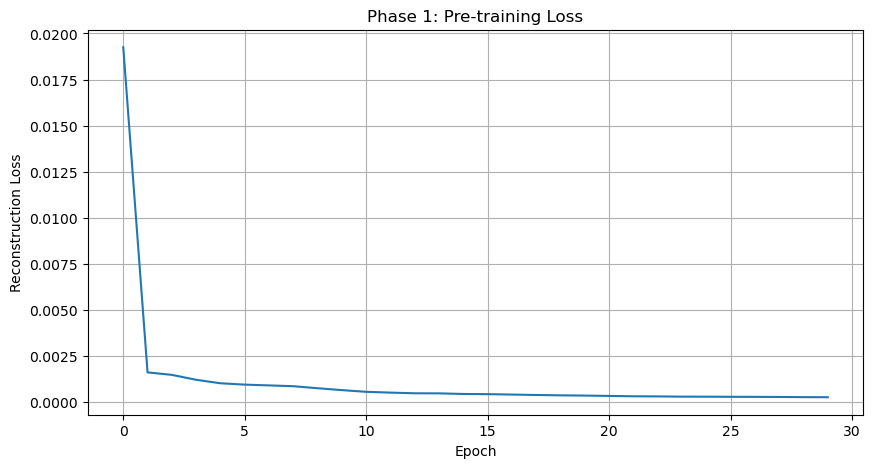

In [11]:
# Train Phase 1
phase1_losses = train_phase1(model, train_loader, num_epochs=30, lr=1e-3)

# Plot losses
plt.figure(figsize=(10, 5))
plt.plot(phase1_losses)
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss')
plt.title('Phase 1: Pre-training Loss')
plt.grid(True)
plt.show()

### Phase 2: Main Training (DSVDD-style)

1. Compute center from training data
2. Train with combined loss: distance to center + reconstruction

In [12]:
def initialize_center(model, train_loader):
    """Compute center as mean of latent representations."""
    print('\nInitializing center...')
    
    model.eval()
    latents = []
    
    with torch.no_grad():
        for batch in tqdm(train_loader, desc='Computing center'):
            neighborhood = batch.to(device)
            z, _ = model.encode(neighborhood)
            latents.append(z)
    
    latents = torch.cat(latents, dim=0)
    center = latents.mean(dim=0)
    
    model.center = center
    model.center_initialized = True
    
    print(f'Center shape: {center.shape}')
    print(f'Center norm: {center.norm().item():.4f}')
    
    return center

In [13]:
def train_phase2(model, train_loader, num_epochs=50, lr=1e-4, alpha=0.1):
    """Phase 2: Main training with DSVDD-style loss."""
    print('\n=== Phase 2: Main Training (DSVDD-style) ===')
    
    # Initialize center
    initialize_center(model, train_loader)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    losses = []
    center_losses = []
    recon_losses = []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        epoch_center_loss = 0
        epoch_recon_loss = 0
        
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            neighborhood = batch.to(device)
            
            optimizer.zero_grad()
            
            # Compute reconstruction loss
            recon_loss, z = compute_reconstruction_loss(model, neighborhood)
            
            # Compute center loss (distance to center)
            center_loss = torch.mean(torch.sum((z - model.center) ** 2, dim=1))
            
            # Combined loss
            loss = center_loss + alpha * recon_loss
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            epoch_center_loss += center_loss.item()
            epoch_recon_loss += recon_loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        avg_center_loss = epoch_center_loss / len(train_loader)
        avg_recon_loss = epoch_recon_loss / len(train_loader)
        
        losses.append(avg_loss)
        center_losses.append(avg_center_loss)
        recon_losses.append(avg_recon_loss)
        
        print(f'Epoch {epoch+1}/{num_epochs}, '
              f'Loss: {avg_loss:.6f}, '
              f'Center: {avg_center_loss:.6f}, '
              f'Recon: {avg_recon_loss:.6f}')
    
    return losses, center_losses, recon_losses


=== Phase 2: Main Training (DSVDD-style) ===

Initializing center...


Computing center: 100%|██████████| 397/397 [00:01<00:00, 309.37it/s]


Center shape: torch.Size([64])
Center norm: 4.2626


Epoch 1/30: 100%|██████████| 397/397 [00:01<00:00, 221.72it/s]


Epoch 1/30, Loss: 0.256835, Center: 0.256785, Recon: 0.000499


...

Epoch 28/30, Loss: 0.000296, Center: 0.000260, Recon: 0.000366


Epoch 29/30: 100%|██████████| 397/397 [00:01<00:00, 237.69it/s]


Epoch 29/30, Loss: 0.000276, Center: 0.000239, Recon: 0.000365


Epoch 30/30: 100%|██████████| 397/397 [00:01<00:00, 213.30it/s]


Epoch 30/30, Loss: 0.000269, Center: 0.000233, Recon: 0.000365


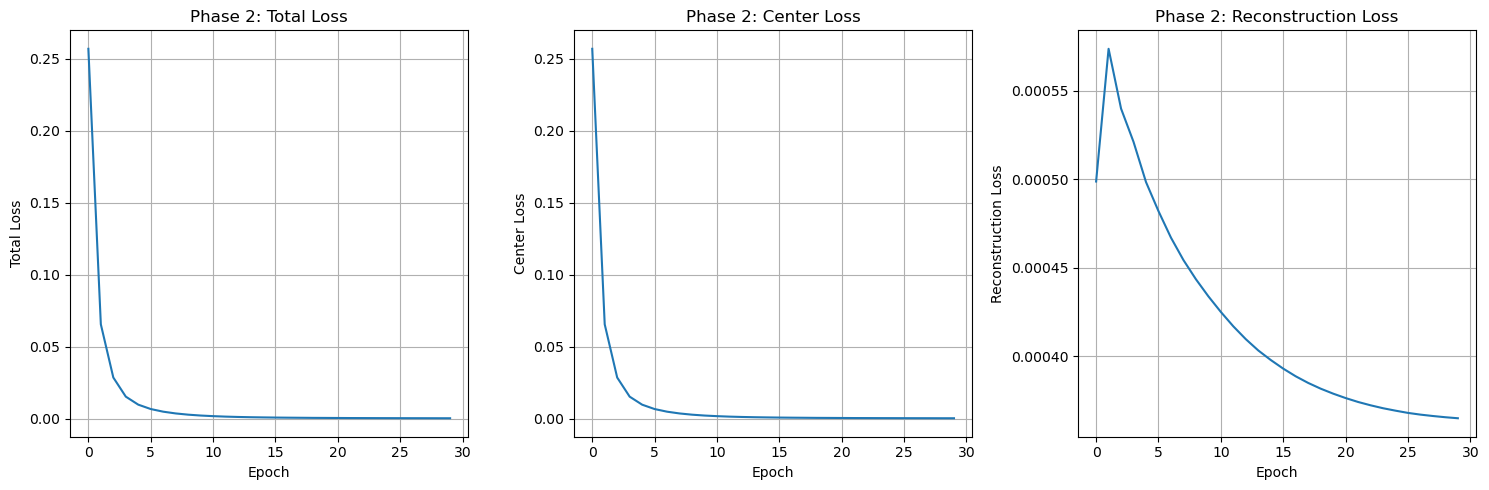

In [14]:
# Train Phase 2
phase2_losses, phase2_center_losses, phase2_recon_losses = train_phase2(
    model, train_loader, num_epochs=30, lr=1e-4, alpha=0.1
)

# Plot losses
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(phase2_losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Phase 2: Total Loss')
axes[0].grid(True)

axes[1].plot(phase2_center_losses)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Center Loss')
axes[1].set_title('Phase 2: Center Loss')
axes[1].grid(True)

axes[2].plot(phase2_recon_losses)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Reconstruction Loss')
axes[2].set_title('Phase 2: Reconstruction Loss')
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 4. Inference and Evaluation

Anomaly score: ||z - c||² (DSVDD center-based, no reconstruction-based scoring)

In [15]:
def evaluate(model, test_loader, test_dataset):
    """Evaluate model on test set."""
    print('\nEvaluating...')
    
    model.eval()
    all_scores = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Computing scores'):
            neighborhood, labels = batch
            neighborhood = neighborhood.to(device)
            
            # Compute anomaly scores
            scores = model.compute_anomaly_score(neighborhood)
            
            all_scores.append(scores.cpu())
            all_labels.append(labels)
    
    all_scores = torch.cat(all_scores).numpy()
    all_labels = torch.cat(all_labels).numpy()
    
    # Convert labels to binary (0=normal, 1=anomaly)
    # Assuming label 2 is normal, others are anomalies
    binary_labels = (all_labels != 2).astype(int)
    
    print(f'Normal pixels: {(binary_labels == 0).sum()}')
    print(f'Anomaly pixels: {(binary_labels == 1).sum()}')
    
    # Compute metrics
    roc_auc = roc_auc_score(binary_labels, all_scores)
    pr_auc = average_precision_score(binary_labels, all_scores)
    
    print(f'\nResults:')
    print(f'ROC-AUC: {roc_auc:.4f}')
    print(f'PR-AUC: {pr_auc:.4f}')
    
    return all_scores, binary_labels, roc_auc, pr_auc

In [16]:
# Evaluate
scores, labels, roc_auc, pr_auc = evaluate(model, test_loader, test_dataset)


Evaluating...


Computing scores: 100%|██████████| 397/397 [00:01<00:00, 337.22it/s]

Normal pixels: 199781
Anomaly pixels: 3199

Results:
ROC-AUC: 0.8976
PR-AUC: 0.5994


/tmp/ipykernel_39426/959196325.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


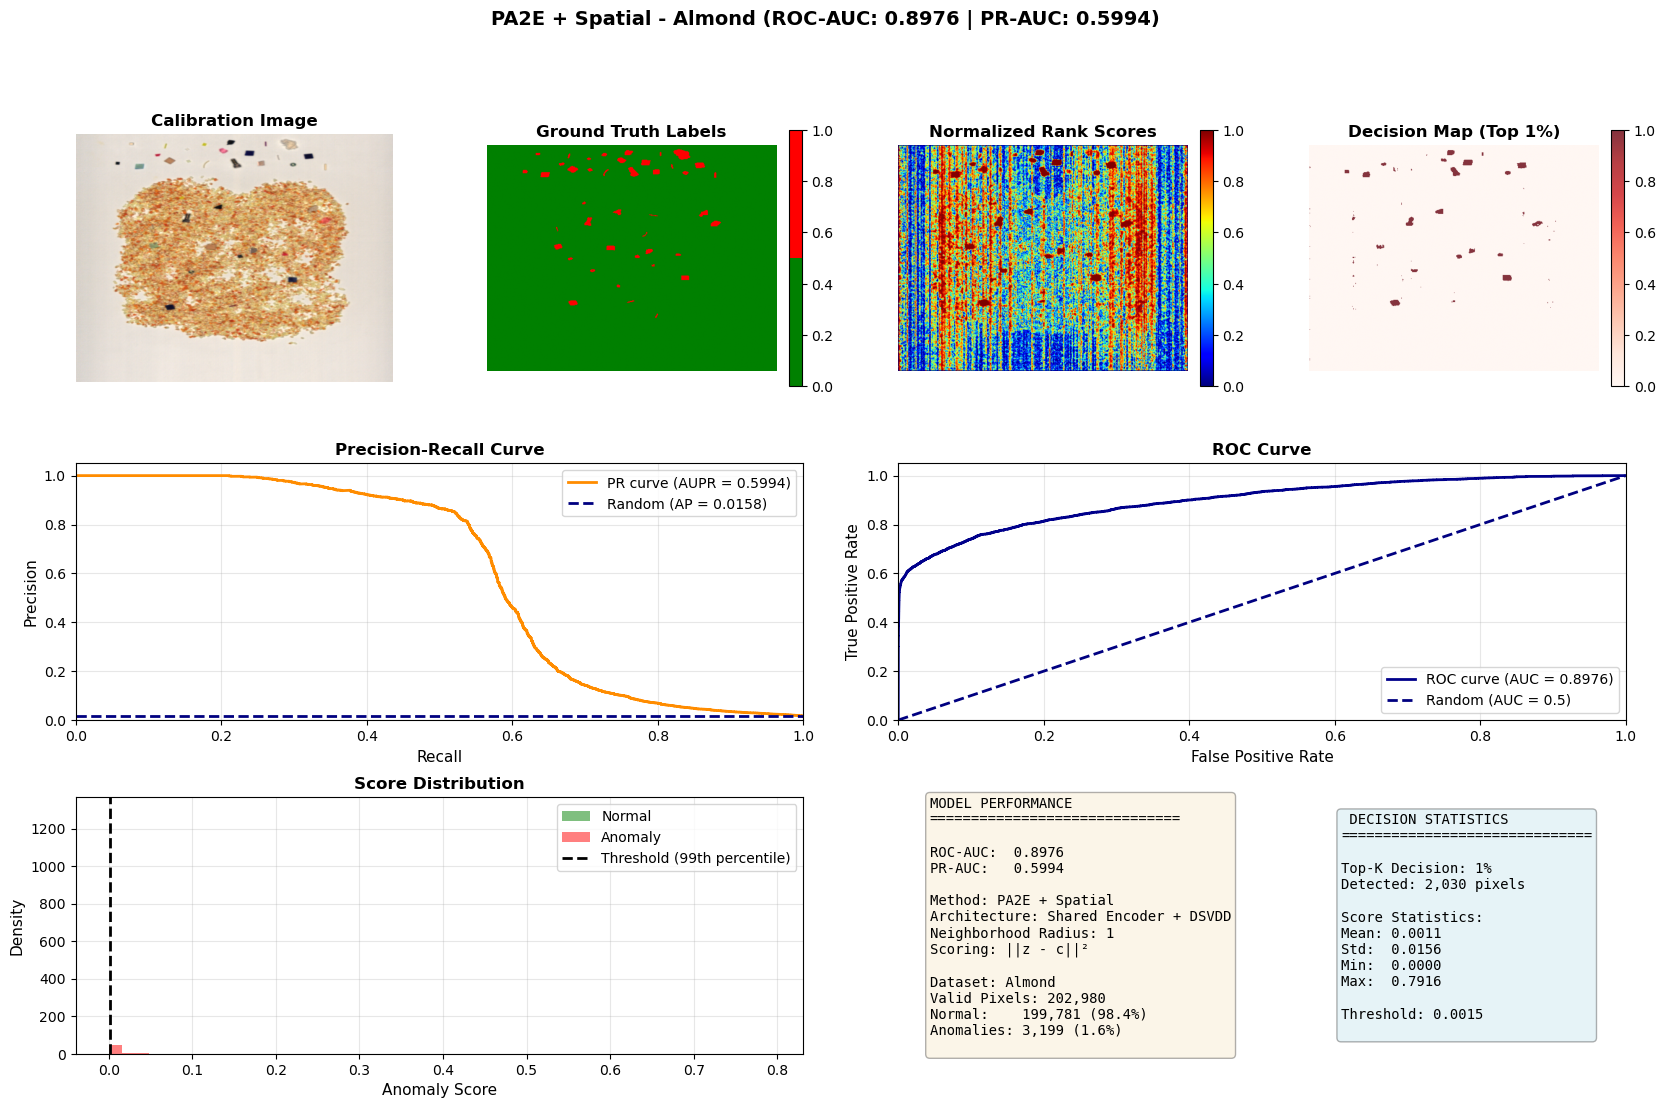


✅ Visualization complete!
   Top-K decision (1%): 2,030 pixels detected as anomalous


In [17]:
# Comprehensive visualization
from scipy.stats import rankdata
from PIL import Image

# Load calibration image
calib_path = f'{base_path}/Test/image_calibration.png'

# Compute normalized rank scores for visualization
rank_scores = rankdata(scores, method="average") / len(scores)
normalized_scores = rank_scores

# Compute decision threshold (top K%)
TOP_K_PERCENT = 1  # Top 1% as anomalies
k_pixels = int(np.ceil(len(scores) * TOP_K_PERCENT / 100.0))
top_k_indices = np.argsort(-scores)[:k_pixels]
pixel_decision = np.zeros(len(scores), dtype=bool)
pixel_decision[top_k_indices] = True

# Reshape for spatial visualization
# Note: we have valid pixels only, need to map back to full spatial grid
H, W = test_dataset.shape
r = neighborhood_radius

# Create full spatial maps
score_map = np.zeros((H, W))
normalized_score_map = np.zeros((H, W))
label_map = np.zeros((H, W))
decision_map = np.zeros((H, W))

# Fill in scores for valid pixels
for idx, (i, j) in enumerate(test_dataset.valid_pixels):
    score_map[i, j] = scores[idx]
    normalized_score_map[i, j] = normalized_scores[idx]
    label_map[i, j] = labels[idx]
    decision_map[i, j] = pixel_decision[idx]

# Create comprehensive figure
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Row 1: Spatial visualizations
ax1 = fig.add_subplot(gs[0, 0])
if os.path.exists(calib_path):
    calib_img = Image.open(calib_path)
    ax1.imshow(calib_img)
    ax1.set_title('Calibration Image', fontsize=12, fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'Calibration Image\nNot Found', ha='center', va='center', fontsize=12)
    ax1.set_title('Calibration Image', fontsize=12, fontweight='bold')
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 1])
from matplotlib.colors import ListedColormap
cmap_binary = ListedColormap(['green', 'red'])
im2 = ax2.imshow(label_map, cmap=cmap_binary)
ax2.set_title('Ground Truth Labels', fontsize=12, fontweight='bold')
ax2.axis('off')
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(normalized_score_map, cmap='jet')
ax3.set_title('Normalized Rank Scores', fontsize=12, fontweight='bold')
ax3.axis('off')
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

ax4 = fig.add_subplot(gs[0, 3])
im4 = ax4.imshow(decision_map, cmap='Reds', alpha=0.8)
ax4.set_title(f'Decision Map (Top {TOP_K_PERCENT}%)', fontsize=12, fontweight='bold')
ax4.axis('off')
plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)

# Row 2: PR and ROC curves
ax5 = fig.add_subplot(gs[1, 0:2])
precision, recall, _ = precision_recall_curve(labels, scores)
ax5.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (AUPR = {pr_auc:.4f})')
baseline = labels.sum() / len(labels)
ax5.plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', label=f'Random (AP = {baseline:.4f})')
ax5.set_xlim([0.0, 1.0])
ax5.set_ylim([0.0, 1.05])
ax5.set_xlabel('Recall', fontsize=11)
ax5.set_ylabel('Precision', fontsize=11)
ax5.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax5.legend(loc='best')
ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2:4])
fpr, tpr, _ = roc_curve(labels, scores)
ax6.plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax6.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5)')
ax6.set_xlim([0.0, 1.0])
ax6.set_ylim([0.0, 1.05])
ax6.set_xlabel('False Positive Rate', fontsize=11)
ax6.set_ylabel('True Positive Rate', fontsize=11)
ax6.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax6.legend(loc='lower right')
ax6.grid(True, alpha=0.3)

# Row 3: Distribution and statistics
ax7 = fig.add_subplot(gs[2, 0:2])
ax7.hist(scores[labels == 0], bins=50, alpha=0.5, label='Normal', color='green', density=True)
ax7.hist(scores[labels == 1], bins=50, alpha=0.5, label='Anomaly', color='red', density=True)
ax7.axvline(np.percentile(scores, 100 - TOP_K_PERCENT), color='black', linestyle='--', 
            label=f'Threshold ({100-TOP_K_PERCENT}th percentile)', linewidth=2)
ax7.set_xlabel('Anomaly Score', fontsize=11)
ax7.set_ylabel('Density', fontsize=11)
ax7.set_title('Score Distribution', fontsize=12, fontweight='bold')
ax7.legend()
ax7.grid(True, alpha=0.3)

ax8 = fig.add_subplot(gs[2, 2])
stats_text_left = f"""MODEL PERFORMANCE
{'='*30}

ROC-AUC:  {roc_auc:.4f}
PR-AUC:   {pr_auc:.4f}

Method: PA2E + Spatial
Architecture: Shared Encoder + DSVDD
Neighborhood Radius: {neighborhood_radius}
Scoring: ||z - c||²

Dataset: {food_type}
Valid Pixels: {len(scores):,}
Normal:    {(labels == 0).sum():,} ({100*(labels==0).sum()/len(labels):.1f}%)
Anomalies: {(labels == 1).sum():,} ({100*(labels==1).sum()/len(labels):.1f}%)
"""
ax8.text(0.1, 0.5, stats_text_left, fontsize=10, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax8.axis('off')

ax9 = fig.add_subplot(gs[2, 3])
stats_text_right = f""" DECISION STATISTICS
{'='*30}

Top-K Decision: {TOP_K_PERCENT}%
Detected: {pixel_decision.sum():,} pixels

Score Statistics:
Mean: {scores.mean():.4f}
Std:  {scores.std():.4f}
Min:  {scores.min():.4f}
Max:  {scores.max():.4f}

Threshold: {np.percentile(scores, 100 - TOP_K_PERCENT):.4f}
"""
ax9.text(0.1, 0.5, stats_text_right, fontsize=10, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax9.axis('off')

plt.suptitle(f'PA2E + Spatial - {food_type} (ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f})', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print(f"\n✅ Visualization complete!")
print(f"   Top-K decision ({TOP_K_PERCENT}%): {pixel_decision.sum():,} pixels detected as anomalous")

In [18]:
# Save model
save_path = f'pa2e_spatial_{food_type.lower()}.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'center': model.center,
    'roc_auc': roc_auc,
    'pr_auc': pr_auc,
    'config': {
        'input_dim': input_dim,
        'neighborhood_size': neighborhood_size,
        'neighborhood_radius': neighborhood_radius,
        'hidden_dim': 128,
        'latent_local_dim': 32,
        'latent_global_dim': 64
    }
}, save_path)

print(f'Model saved to {save_path}')

Model saved to pa2e_spatial_almond.pth
